# 1.8) Statistical Foundations and the Machine-Learning Stepping-Stone

This closing subchapter covers the three pillars of statistical modelling with scikit-learn, then the statistical graphics of seaborn. Regression comes first: a linear fit of air temperature against elevation recovers the environmental lapse rate, through the scikit-learn estimator interface (instantiate, fit, predict) and an honest evaluation on held-out data with RMSE and the coefficient of determination. Clustering follows — k-means, the choice of the number of clusters, and PCA, on real Palmer Archipelago penguin measurements — and then classification, separating two penguin species by the shape of their bills. The estimator-as-object pattern is the one introduced in the object-oriented subchapter. The seaborn half explores distributions, facets, categories, and correlations. At the end, the generated code judges a model by how well it fits the data it was trained on: a near-perfect score on the training set, and a badly wrong prediction on new points.

```{figure} _static/scikit_learn_logo.svg
---
name: scikit-learn-logo
width: 400px
alt: The scikit-learn project logo
---
The scikit-learn logo, from the project's own <a href="https://github.com/scikit-learn/scikit-learn/blob/main/doc/logos/scikit-learn-logo.svg">repository</a>, BSD-3-Clause licensed.
```

:::{admonition} **Learning objectives**
:class: tip
- Use the scikit-learn estimator interface: instantiate, fit, predict, with the X/y convention, across its three pillars — regression, clustering, and classification.
- Fit a linear regression for the lapse rate, split data into train and test sets, evaluate with RMSE and R^2, and recognise overfitting.
- Group unlabelled observations with `KMeans`, choose k with the elbow method and the silhouette score, and summarise correlated features with `PCA`.
- Standardise features, chain steps with a Pipeline, fit a linear classifier (`LogisticRegression`), and read its weights and decision boundary.
- Explore data with seaborn, a layer over matplotlib: histograms and KDEs split by `hue=`, joint distributions, and regression plots.
- Know where a KDE misleads: bounded data and the choice of smoothing.
- Compare groups with faceted histograms, box plots, count and bar plots, and summarise tables and correlations as heat maps.
:::

## 1.8.1 Introduction

[scikit-learn](https://scikit-learn.org/stable/) covers three pillars of statistical modelling, and this subchapter touches all three: *regression*, which learns the relationship between continuous inputs (predictors, or features) and a continuous output (the predictand, or target); *clustering*, which groups observations that resemble each other without being told what the groups are; and *classification*, which learns which of a set of classes an observation belongs to.

## 1.8.2 Linear Regression

Linear regression is the simplest regression model. Given measurements of how one physical property $y$ depends on another, $x$, it predicts $\hat{y} = wx + b$, with slope $w$ and intercept $b$ chosen to fit the data.

The data here are synthetic: a set of stations whose air temperature falls with elevation at the environmental lapse rate of −6.5 °C km⁻¹, plus noise, so that the relationship the regression should recover is known exactly. A loosely elevation-dependent count of snow days comes along for later.

In [ ]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
n = 80
elevation_m = rng.uniform(200, 3500, n)
temp_celsius = 15.0 - 6.5 * (elevation_m / 1000) + rng.normal(0, 1.5, n)
snow_days = 20 + 0.02 * elevation_m + rng.normal(0, 10, n)
df = pd.DataFrame({"elevation_m": elevation_m, "temp_celsius": temp_celsius, "snow_days": snow_days})
print(df.describe().round(2))

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.scatter(df["elevation_m"], df["temp_celsius"], s=15)
ax.set_xlabel("elevation (m)")
ax.set_ylabel("temperature (°C)")
plt.show()

Can the lapse rate be found from these points alone? Every scikit-learn model is an object used the same way: instantiate it, `fit` it to a feature matrix `X` and target vector `y`, then `predict`. By convention `X` is two-dimensional with shape (n_samples, n_features) and `y` is one-dimensional. The fitted parameters are stored on attributes ending in an underscore.

For a straight line $\hat{y} = wx + b$, `fit` chooses the slope $w$ and intercept $b$ that minimise the sum of squared errors

$$J(w, b) = \sum_{i=1}^{N}\left(y_i - \hat{y}_i\right)^2,$$

solved directly rather than by trial and error. Least squares is what makes the fitted line the one that passes as close as possible to every point at once.

In [6]:
from sklearn.linear_model import LinearRegression

X = df[["elevation_m"]]     # 2D feature matrix (note the double brackets)
y = df["temp_celsius"]      # 1D target

model = LinearRegression().fit(X, y)
lapse_rate = model.coef_[0] * 1000          # °C per km
print("recovered lapse rate:", round(lapse_rate, 2), "°C km^-1")
print("intercept (sea-level temp):", round(model.intercept_, 2), "°C")
print("prediction at 2000 m:", round(model.predict(pd.DataFrame({"elevation_m": [2000]}))[0], 2), "°C")

recovered lapse rate: -6.67 °C km^-1
intercept (sea-level temp): 15.31 °C
prediction at 2000 m: 1.96 °C


In [ ]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.scatter(df["elevation_m"], df["temp_celsius"], s=15, alpha=0.6, label="data")
ax.plot(df["elevation_m"], model.predict(X), color="k", linewidth=2, label="model")
ax.set_xlabel("elevation (m)")
ax.set_ylabel("temperature (°C)")
ax.legend()
plt.show()

The recovered lapse rate is close to the −6.5 °C km⁻¹ built into the data, but not exact: 80
noisy stations only pin it down so far. More data narrows the gap.

In [ ]:
for n_stations in (80, 800, 8000):
    elev = rng.uniform(200, 3500, n_stations)
    temp = 15.0 - 6.5 * (elev / 1000) + rng.normal(0, 1.5, n_stations)
    fitted = LinearRegression().fit(elev.reshape(-1, 1), temp)
    print(f"{n_stations:5d} stations -> lapse rate {fitted.coef_[0] * 1000:6.2f} °C km^-1, "
          f"intercept {fitted.intercept_:5.2f} °C")

### Evaluating on held-out data

A model must be judged on data it has not seen. `train_test_split` holds out a test set; the root-mean-square error (RMSE) reports the typical error in the target's units, and R^2 the fraction of variance explained.

test RMSE: 1.595 °C
test R^2:  0.947


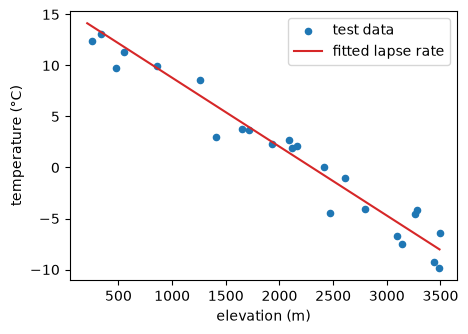

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

print("test RMSE:", round(root_mean_squared_error(y_test, y_pred), 3), "°C")
print("test R^2: ", round(r2_score(y_test, y_pred), 3))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.scatter(X_test["elevation_m"], y_test, s=20, label="test data")
grid = pd.DataFrame({"elevation_m": np.linspace(X["elevation_m"].min(), X["elevation_m"].max(), 100)})
ax.plot(grid["elevation_m"], model.predict(grid), color="tab:red", label="fitted lapse rate")
ax.set_xlabel("elevation (m)")
ax.set_ylabel("temperature (°C)")
ax.legend()
plt.show()

:::{admonition} Computational-thinking fundamental: evaluate on data the model has not seen
:class: important
The goal of a model is to generalise, so its performance is what it achieves on unseen data — never on the data it was fitted to. A sufficiently flexible model can fit any training set perfectly, including its noise, while predicting new points badly. The train/test split (and, better, cross-validation) exists to measure generalisation rather than memorisation. A model scored only on its training data can report an R^2 near 1.0 and still be badly wrong on the very next new point it sees.
:::

## 1.8.3 Clustering

Regression finds a relationship between inputs and a known output. Some questions have no output to learn: given many unlabelled measurements, which observations belong together? Clustering answers that, and a clustering can help interpret a complex, high-dimensional dataset. scikit-learn implements [many clustering algorithms](https://scikit-learn.org/stable/modules/clustering.html); this section uses the most common one.

### k-means clustering

```{figure} _static/kmeans-expectation-maximization.png
---
name: kmeans-iterations
width: 100%
alt: Four panels showing successive k-means iterations, the cluster centres moving and the point colours settling as the algorithm converges
---
Four successive iterations of k-means on the same points. Each panel assigns every point to its
nearest centre and then moves each centre to the mean of the points assigned to it; by the fourth
panel neither step changes anything and the algorithm has converged. Figure from Jake VanderPlas,
<a href="https://github.com/jakevdp/PythonDataScienceHandbook">Python Data Science Handbook</a>
(code MIT-licensed).
```

The algorithm alternates two steps until neither changes anything, and it never sees a label.

`KMeans` partitions points into `n_clusters` groups by repeatedly assigning each point to the
nearest centroid and moving each centroid to the mean of its group. It is easiest to see on data
built to have clusters: `make_blobs` draws points around a chosen number of centres, and the
fitted centroids land on them.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X_blobs, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
km_blobs = KMeans(n_clusters=4, random_state=0, n_init=10).fit(X_blobs)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], s=15, color="0.5")
axes[0].set_title("300 points, no labels")

axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=km_blobs.labels_, s=15, cmap="viridis")
axes[1].scatter(*km_blobs.cluster_centers_.T, marker="s", s=140, c="white",
                edgecolors="k", linewidths=2, label="centroids")
axes[1].set_title("k-means clusters (k=4)")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
plt.tight_layout()
plt.show()

### The Palmer Penguins dataset

The **Palmer Penguins** dataset was collected by Kristen Gorman at Palmer Station, Antarctica. It holds 344 records of the physical attributes of penguins in the Palmer Archipelago, belonging to three species; two records have no body measurements at all and are dropped below, leaving 342 (Horst, Hill & Gorman, 2020; *palmerpenguins*, doi:10.5281/zenodo.3960218; data collected by the Palmer Station Antarctica LTER and K. Gorman).

```{figure} _static/palmerpenguins-species.jpg
---
name: palmerpenguins-species
width: 700px
alt: Illustrations of the three penguin species in the dataset — Chinstrap, Gentoo and Adelie
---
The three species in the dataset. Artwork by Allison Horst (`@allison_horst`), from the
<a href="https://allisonhorst.github.io/palmerpenguins/">palmerpenguins</a> package. Data by
K. Gorman and the Palmer Station Antarctica LTER, released under CC-0.
```

In [2]:
# Pre-supplied: download the data file and cache it locally.
# You do not need to understand this cell yet — fetching data is covered in the
# reproducible-data-pipelines bonus subchapter.
import pooch

penguins_path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/palmer_penguins.csv",
    known_hash="sha256:f204db2c753b0937caac3cb35258562c14f073e4bbc76be24b4c51ce22767a93",
    fname="palmer_penguins.csv",
    path=pooch.os_cache("mlees"),
)

penguins = pd.read_csv(penguins_path).dropna(
    subset=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
).reset_index(drop=True)

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4))
for species, group in penguins.groupby("species"):
    ax.scatter(group["body_mass_g"], group["flipper_length_mm"], s=18, label=species)
ax.set_xlabel("body mass (g)")
ax.set_ylabel("flipper length (mm)")
ax.grid(linestyle="--", alpha=0.3)
ax.legend()
plt.show()

On a real dataset the clusters are rarely that obliging. The penguin measurements below have no
species column as far as `KMeans` is concerned — it sees two physical measurements and nothing
else.

In [ ]:
from sklearn.cluster import KMeans

X_cluster = penguins[["flipper_length_mm", "body_mass_g"]]
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10).fit(X_cluster)
penguins["cluster"] = kmeans.labels_

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for species, group in penguins.groupby("species"):
    axes[0].scatter(group["flipper_length_mm"], group["body_mass_g"], s=15, label=species)
axes[0].set_title("true species")
axes[0].legend(fontsize=8)

axes[1].scatter(X_cluster["flipper_length_mm"], X_cluster["body_mass_g"],
                c=penguins["cluster"], s=15, cmap="viridis")
axes[1].scatter(*kmeans.cluster_centers_.T, marker="x", s=100, color="black", label="centroids")
axes[1].set_title("k-means clusters (k=3)")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("flipper length (mm)")
    ax.set_ylabel("body mass (g)")
plt.tight_layout()
plt.show()

# crosstab counts how many of each true species fall into each cluster
print(pd.crosstab(penguins["species"], penguins["cluster"]))

Two features are not quite enough to cleanly separate three species by shape alone: Gentoo (heavier, longer-flippered) forms its own cluster, but Adelie and Chinstrap overlap and mix into the other two clusters — the crosstab shows exactly where. Clustering finds structure in the *features you give it*; it cannot recover a label the features do not distinguish.

What if the number of clusters is set to two instead?

In [ ]:
kmeans2 = KMeans(n_clusters=2, random_state=0, n_init=10).fit(X_cluster)
penguins["cluster2"] = kmeans2.labels_

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.scatter(X_cluster["flipper_length_mm"], X_cluster["body_mass_g"],
           c=penguins["cluster2"], s=15, cmap="viridis")
ax.scatter(*kmeans2.cluster_centers_.T, marker="x", s=100, color="black", label="centroids")
ax.set_xlabel("flipper length (mm)")
ax.set_ylabel("body mass (g)")
ax.set_title("k-means clusters (k=2)")
ax.legend(fontsize=8)
plt.show()
print(pd.crosstab(penguins["species"], penguins["cluster2"]))

Two clusters look more natural in this plane than three: one holds Gentoo, the other Adelie and Chinstrap together. Which number is right should not be decided by eye.

### Choosing k: the elbow method

We fixed `k=3` because we already know there are three species — in general the right number of clusters is not known in advance. The elbow method refits `KMeans` across a range of `k` and plots the inertia (each point's squared distance to its cluster's centroid, summed over every point): inertia always falls as `k` grows, but the rate of improvement drops sharply once extra clusters stop capturing real structure — a bend, or "elbow", in the curve.

In [ ]:
inertias = []
k_values = range(1, 7)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(list(k_values), inertias, marker="o")
ax.set_xlabel("number of clusters (k)")
ax.set_ylabel("inertia")
ax.set_title("elbow method")
plt.show()

#### Silhouette analysis

The elbow is not always sharp: here the curve bends somewhere between two and four clusters
without saying which. The *silhouette score* puts a number on it. For one observation,

$$S = \frac{b - a}{\max(a, b)},$$

where $a$ is its mean distance to the other points in its own cluster and $b$ its mean distance to
the points of the nearest other cluster. A value near 1 means the observation sits comfortably
inside its own cluster; near 0 means it sits on the boundary between two. Averaged over every
observation, the score can be compared across `k`, and the largest average wins.

In [ ]:
from sklearn.metrics import silhouette_score

scores = []
k_range = range(2, 7)
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=0, n_init=10).fit_predict(X_cluster)
    scores.append(silhouette_score(X_cluster, labels))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(list(k_range), scores, marker="s", color="k", lw=2)
ax.set_xlabel("number of clusters (k)")
ax.set_ylabel("mean silhouette score")
ax.set_title("silhouette analysis")
plt.show()

for k, s in zip(k_range, scores):
    print(f"k={k}: {s:.3f}")

Two clusters score highest — and two clusters is not three species. Both diagnostics are
answering the question they were asked, which is how well-separated the groups in *these two
features* are, not how many species the archipelago holds. A clustering that scores well can
still be the wrong grouping for the question you care about.

That is a statement about the *features*, not about the algorithm. Gentoo separates because it is
heavier and longer-flippered than the other two; Adelie and Chinstrap overlap because in this
plane they genuinely are alike. Swap body mass for bill length, and the same three species come
apart — Chinstrap flippers resemble Adelie's, but Chinstrap bills resemble Gentoo's.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for species, group in penguins.groupby("species"):
    axes[0].scatter(group["body_mass_g"], group["flipper_length_mm"], s=18, label=species)
    axes[1].scatter(group["bill_length_mm"], group["flipper_length_mm"], s=18, label=species)

axes[0].set_xlabel("body mass (g)")
axes[0].set_title("the plane clustered above")
axes[1].set_xlabel("bill length (mm)")
axes[1].set_title("a plane that separates the species")
for ax in axes:
    ax.set_ylabel("flipper length (mm)")
    ax.grid(linestyle="--", alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Two of the four measurements describe the bill. The raw data calls them *culmen* length and
depth, after the ridge along the top of the bill; the column names here use the plainer word.

```{figure} _static/palmerpenguins-bill-dimensions.jpg
---
name: palmerpenguins-bill-dimensions
width: 600px
alt: A diagram of a penguin head showing which dimension is bill length and which is bill depth
---
What `bill_length_mm` and `bill_depth_mm` measure. Artwork by Allison Horst (`@allison_horst`), from the
<a href="https://allisonhorst.github.io/palmerpenguins/">palmerpenguins</a> package.
```

### Dimensionality reduction with PCA

`PCA` finds new axes — linear combinations of the original features — ordered by how much variance they capture, so a handful of components can summarise many correlated measurements. Scale first, with `StandardScaler`, which subtracts each feature's mean and divides by its standard deviation: PCA follows variance, so without scaling, body mass, in thousands of grams, would dominate bill depth, in tens of millimetres.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
Xs = StandardScaler().fit_transform(penguins[features])
pca = PCA(n_components=2).fit(Xs)
scores = pca.transform(Xs)
penguins["pc1"], penguins["pc2"] = scores[:, 0], scores[:, 1]
print("explained variance ratio:", pca.explained_variance_ratio_.round(3))

fig, ax = plt.subplots(figsize=(5.5, 4))
for species, group in penguins.groupby("species"):
    ax.scatter(group["pc1"], group["pc2"], s=15, label=species)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)")
ax.set_title("penguin measurements, reduced to two components")
ax.legend(fontsize=8)
plt.show()

Unlike k-means, PCA needs no target and no assumed number of groups — here the first two components already separate the three species almost as cleanly as the full four-feature space, using all four correlated measurements at once instead of picking two by hand.

## 1.8.4 Linear Classification

Not every target is continuous. When `y` is a category, a classifier follows the identical `fit`/`predict` interface. `LogisticRegression` is the classification analogue of linear regression: it fits a linear boundary in feature space and reports, for each observation, the probability that it belongs to each class.

The bill plane separated the species where body mass could not. Here, the task is to tell an Adelie from a Chinstrap using nothing but the two bill measurements. Gentoo is left out — it is the easy case, separable on almost any pair of features — leaving the two species that overlap.

Look at the two measurements one at a time first. Bill length separates the two species almost completely; bill depth barely separates them at all.

In [ ]:
two_species = penguins[penguins["species"].isin(["Adelie", "Chinstrap"])]
bill_columns = ["bill_length_mm", "bill_depth_mm"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, column in zip(axes, bill_columns):
    for species, group in two_species.groupby("species"):
        ax.hist(group[column], bins=20, alpha=0.5, label=species)
    ax.set_xlabel(f"{column.replace('_', ' ')}")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

A classifier must also be judged on observations it was not trained on, so the data are split first.

In [ ]:
from sklearn.linear_model import LogisticRegression

X_bill = two_species[bill_columns]
y_species = two_species["species"]
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bill, y_species, test_size=0.3, random_state=0, stratify=y_species
)
print(Xb_train.describe().round(2))

### Standardisation and pipelines

Bill length runs from roughly 32 to 58 mm and bill depth from 15 to 21, so the two features differ in scale by about a factor of three. Left alone, the fitted weights would reflect that difference as much as the information in the features. *Standardisation* removes it: subtract each feature's mean and divide by its standard deviation,

$$x_{\text{standard}} = \frac{x - \operatorname{mean}(x)}{\operatorname{std}(x)},$$

so that every feature has mean 0 and standard deviation 1, in units of its own spread.

In [ ]:
length_standard = (Xb_train["bill_length_mm"] - Xb_train["bill_length_mm"].mean()) / Xb_train["bill_length_mm"].std(ddof=0)
depth_standard = (Xb_train["bill_depth_mm"] - Xb_train["bill_depth_mm"].mean()) / Xb_train["bill_depth_mm"].std(ddof=0)
print("bill length:", round(length_standard.min(), 2), "to", round(length_standard.max(), 2))
print("bill depth: ", round(depth_standard.min(), 2), "to", round(depth_standard.max(), 2))

`StandardScaler` does the same thing as an estimator. A `Pipeline` chains preprocessing and model into one estimator, so the scaler is fitted on the training data only — which is exactly what prevents information from the test set leaking into training. Many estimators (regularised regressions, distance-based methods, and `LogisticRegression`, which is regularised by default) need features on comparable scales.

In [ ]:
from sklearn.pipeline import make_pipeline

bill_clf = make_pipeline(StandardScaler(), LogisticRegression())
bill_clf.fit(Xb_train, yb_train)
print("test accuracy:", round(bill_clf.score(Xb_test, yb_test), 3))

A pipeline is used exactly like the estimator at its end. For a regression, `.score` reports R^2 instead of accuracy:

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pipe = make_pipeline(StandardScaler(), LinearRegression())
pipe.fit(X_train, y_train)
print("pipeline test R^2:", round(pipe.score(X_test, y_test), 3))
# for ordinary least squares, scaling leaves predictions unchanged; the habit matters
# for regularised and distance-based models, where unscaled features distort the fit

The fitted model is a straight line through the standardised bill plane: one weight per feature
plus an intercept. Reading the weights says which measurement the decision actually rests on.

In [ ]:
weights = pd.Series(bill_clf[-1].coef_[0], index=bill_columns)
intercept = bill_clf[-1].intercept_[0]
print(weights.round(2))
print("intercept:", round(intercept, 2))

fig, ax = plt.subplots(figsize=(5, 2.4))
weights.plot.barh(ax=ax, color="tab:blue")
ax.axvline(0, color="k", linewidth=0.8)
ax.set_xlabel("weight (standardised features)")
ax.set_title("logistic regression weights")
plt.tight_layout()
plt.show()

# the boundary is the line where the weighted sum crosses zero:
#     w1 * bill_length + w2 * bill_depth + intercept = 0
# bill length carries the larger weight, matching the histograms above

Predicting the class of every point on a fine grid draws that line directly: the decision boundary, with the test penguins on top.

In [ ]:
length_grid, depth_grid = np.meshgrid(np.linspace(32, 60, 300), np.linspace(15, 22, 300))
grid_points = pd.DataFrame({"bill_length_mm": length_grid.reshape(-1),
                            "bill_depth_mm": depth_grid.reshape(-1)})
is_chinstrap = (bill_clf.predict(grid_points) == "Chinstrap").reshape(length_grid.shape)

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.contourf(length_grid, depth_grid, is_chinstrap.astype(int), levels=[-0.5, 0.5, 1.5],
            colors=["tab:blue", "tab:red"], alpha=0.25)
for species, color in [("Adelie", "tab:blue"), ("Chinstrap", "tab:red")]:
    test_birds = Xb_test[yb_test == species]
    ax.scatter(test_birds["bill_length_mm"], test_birds["bill_depth_mm"],
               color=color, edgecolors="k", s=25, label=species)
ax.set_xlabel("bill length (mm)")
ax.set_ylabel("bill depth (mm)")
ax.set_title("decision boundary of the logistic regression")
ax.legend(title="test set")
plt.show()

The few test birds on the wrong side of the line are the misclassifications behind the test accuracy above.

## 1.8.5 Statistical Graphics with seaborn

```{figure} _static/seaborn_logo.svg
---
name: seaborn-logo
width: 500px
alt: The seaborn project logo
---
The seaborn logo, from the project's own <a href="https://seaborn.pydata.org/">documentation</a>.
```

### seaborn versus matplotlib

seaborn is not a replacement for matplotlib but a layer on top of it: pass column names instead of extracted arrays, and get a sensible default style, a legend, and statistical summaries such as densities and fitted trend lines, all in one call. `ax=` still accepts a matplotlib axes, so the two compose rather than compete; reach for matplotlib directly whenever a plot needs more control than seaborn's defaults give you.

Here is a set of random walks drawn with matplotlib's classic style:

In [ ]:
x = np.linspace(0, 10, 500)
walks = np.cumsum(rng.normal(size=(500, 6)), axis=0)

with plt.style.context("classic"):
    plt.plot(x, walks)
    plt.legend(list("ABCDEF"), ncol=2, loc="upper left")
    plt.show()

`sns.set_theme()` replaces matplotlib's default style for every figure that follows, so the same plotting code gives a different figure:

In [ ]:
import seaborn as sns

sns.set_theme()
plt.plot(x, walks)
plt.legend(list("ABCDEF"), ncol=2, loc="upper left")
plt.show()

## 1.8.6 Exploring Datasets with seaborn

seaborn provides high-level commands for the plot types used in statistical data exploration, and some statistical model fitting. Everything below could be done with raw matplotlib commands — which is what seaborn calls underneath — but seaborn's interface is much more convenient.

### Histograms, KDE, and densities

Often in statistical visualisation, all you want is the distribution of a variable, split by group. With matplotlib that takes a loop over the groups:

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for species, group in penguins.groupby("species"):
    ax.hist(group["body_mass_g"], alpha=0.5, label=species)
ax.set_xlabel("body mass (g)")
ax.legend()
plt.show()

`sns.kdeplot` estimates a smooth density for each group instead, and `hue=` splits the data by a categorical column in the same call — no loop needed:

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.kdeplot(data=penguins, x="body_mass_g", hue="species", fill=True, ax=ax)
ax.set_xlabel("body mass (g)")
plt.show()

### KDE

A kernel density estimate (KDE) is analogous to a histogram, but instead of counting observations into bins it places a small smooth bump on each one and adds them up, which gives a continuous estimate of the probability density function. Relative to a histogram, a KDE is less cluttered and easier to read, especially when several distributions are drawn together. It has two weaknesses, both visible below:

- a **bounded** variable, such as precipitation or burned area, which cannot be negative, gets density on the impossible side of its bound, because the bumps spread past it; `cut=0` stops the curve at the most extreme data points;
- the result depends on the **smoothing** (the bandwidth) as much as a histogram depends on its bins; `bw_adjust` scales it, and too much smoothing hides structure while too little invents it.

In [ ]:
precip_mm = pd.Series(rng.exponential(6.0, 300), name="daily precipitation (mm)")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
sns.histplot(precip_mm, stat="density", color="0.85", ax=ax[0])
sns.kdeplot(precip_mm, ax=ax[0], label="default")
sns.kdeplot(precip_mm, ax=ax[0], cut=0, label="cut=0")
ax[0].axvline(0, color="k", linewidth=0.8)
ax[0].set_title("a bounded variable")
ax[0].legend()
for bw in [0.2, 1, 3]:
    sns.kdeplot(data=penguins, x="body_mass_g", bw_adjust=bw, ax=ax[1], label=f"bw_adjust={bw}")
ax[1].set_title("the choice of smoothing")
ax[1].legend()
plt.tight_layout()
plt.show()

`sns.histplot` draws the histogram itself, with the same `data=`/`x=`/`hue=` arguments. `stat="density"` scales the bars so that their area is 1, which puts them on the same axis as a KDE, and `kde=True` overlays one:

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.histplot(data=penguins, x="body_mass_g", hue="species", stat="density", kde=True, alpha=0.4, ax=ax)
ax.set_xlabel("body mass (g)")
plt.show()

`sns.displot` builds the whole figure in one line: `kind=` chooses a histogram or a KDE, `kde=True` overlays the density, and `rug=True` marks every observation along the axis.

In [ ]:
adelie = penguins[penguins["species"] == "Adelie"]
sns.displot(data=adelie, x="body_mass_g", kind="hist", kde=True, rug=True, aspect=1.5)
plt.show()

With `hue=`, the densities are by default normalised *together*, so each group's area is proportional to its share of the data: Chinstrap, with 68 birds against Adelie's 151, gets a smaller curve. `common_norm=False` normalises each group on its own, which compares the *shapes* of the distributions rather than their sizes. Neither is wrong; they answer different questions.

In [ ]:
for common in [True, False]:
    sns.displot(data=penguins, x="body_mass_g", hue="species", kind="kde",
                common_norm=common, height=3, aspect=2)
    plt.title(f"common_norm={common}")
    plt.show()

### Two variables at once

`kdeplot` also works on two variables at once, showing where two measurements co-vary rather than just their individual spreads:

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.kdeplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", ax=ax)
plt.show()

`jointplot` adds the two 1D marginal densities around the 2D view. `kind="kde"` draws densities; `kind="hex"` draws a two-dimensional histogram of hexagonal bins, which suits large datasets better than a scatter. Its other settings are in the [jointplot documentation](https://seaborn.pydata.org/generated/seaborn.jointplot.html).

In [ ]:
sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", kind="kde")

In [ ]:
sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", kind="hex")
plt.show()

seaborn also includes statistical modelling utilities, such as `regplot`, which fits and draws a linear regression with its confidence band — the lapse-rate fit from the start of this subchapter, in one call:

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.regplot(data=df, x="elevation_m", y="temp_celsius", ax=ax,
            scatter_kws={"s": 15}, line_kws={"color": "tab:red"})
ax.set_xlabel("elevation (m)")
ax.set_ylabel("temperature (°C)")
plt.show()

## 1.8.7 Faceted Histograms

Sometimes the best view of a dataset is a grid of histograms of its subsets. [`FacetGrid`](https://seaborn.pydata.org/generated/seaborn.FacetGrid.html) makes one: `row=` and `col=` name the categorical columns that split the data, and `.map` draws the same plot in every panel.

In [ ]:
grid = sns.FacetGrid(penguins, row="sex", col="island", margin_titles=True, height=2.5)
grid.map(plt.hist, "body_mass_g", bins=np.linspace(2500, 6500, 17))
plt.show()

`sns.displot` builds the same kind of grid in one call, with `col=` (and `row=`) on a figure-level plot:

In [ ]:
sns.displot(data=penguins, x="body_mass_g", col="species", bins=15, height=3)
plt.show()

## 1.8.8 Categorical Plots

[`catplot`](https://seaborn.pydata.org/generated/seaborn.catplot.html) relates a numerical variable to one or more categorical ones: it shows how a quantity is distributed within each category, even though one axis is a number and the other a label. `kind=` chooses the representation.

### Box plots

A box plot summarises a distribution's median, quartiles, and outliers per category — more compact than a histogram when comparing several groups at once.

In [ ]:
g = sns.catplot(data=penguins, x="species", y="body_mass_g", hue="sex", kind="box", height=3.5, aspect=1.4)
g.set_axis_labels("species", "body mass (g)")
plt.show()

The axes-level `sns.boxplot` draws the same thing into an axes you created:

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.boxplot(data=penguins, x="species", y="body_mass_g", ax=ax)
ax.set_ylabel("body mass (g)")
plt.show()

### Bar plots

`kind="count"` counts the observations in each category, with no numeric variable at all:

In [ ]:
g = sns.catplot(data=penguins, x="island", hue="species", kind="count", height=3.5, aspect=1.4)
g.set_ylabels("number of penguins")
plt.show()

`sns.barplot` instead aggregates a numeric column per category (the mean, by default) and draws the result with an error bar — a quick alternative to a manual `groupby` and hand-drawn bar chart:

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(data=penguins, x="species", y="flipper_length_mm", ax=ax, errorbar="sd")
ax.set_ylabel("flipper length (mm)")
plt.show()

## 1.8.9 Heat Maps

A heat map shows a matrix as a grid of coloured cells, so a numerical variable can be read as a function of two others, continuous or categorical. `pd.crosstab` counts how often each combination of two categories occurs, and the [heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html) of that table shows which species lives on which island:

In [ ]:
species_by_island = pd.crosstab(penguins["species"], penguins["island"])
print(species_by_island)

fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(species_by_island, annot=True, fmt="d", cmap="BuGn", ax=ax)
plt.show()

Gentoo were measured only on Biscoe and Chinstrap only on Dream, while Adelie appear on all three islands.

A correlation analysis fits in a few characters the same way: `corr` gives the pairwise Pearson correlation of every pair of columns, and the heat map shows the whole matrix at once. Temperature is strongly anti-correlated with elevation — the lapse rate — while snow days rise with it.

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.heatmap(df.corr().round(2), annot=True, cmap="vlag", vmin=-1, vmax=1, ax=ax)
ax.set_title("Pearson correlation")
plt.tight_layout()
plt.show()

## *When generated code lies: scoring on the training data*

Asked to "evaluate the model", an assistant fits a flexible model and reports R^2 on the same data it trained on. On a small, noisy sample a high-degree polynomial fits almost perfectly — and predicts new points disastrously.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

rng2 = np.random.default_rng(1)
x_small = np.linspace(0.2, 3.5, 20)
y_small = 15.0 - 6.5 * x_small + rng2.normal(0, 2.0, 20)   # noisy lapse rate, km
Xs = x_small.reshape(-1, 1)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, y_small, test_size=0.4, random_state=0)

overfit = make_pipeline(PolynomialFeatures(degree=8), LinearRegression()).fit(Xs_tr, ys_tr)
print("degree-8 R^2 on TRAINING data:", round(r2_score(ys_tr, overfit.predict(Xs_tr)), 3))

:::{admonition} Diagnosis: a training score is not performance
:class: warning
The training R^2 near 1.0 only shows that the degree-8 polynomial curve passes close to its own training points — with eight free coefficients it bent to match the noise in that particular sample rather than the underlying trend. Evaluated on held-out data the same model is catastrophic, while the simple linear model — the correct physical form — generalises well. Only the test score reflects how the model performs on data it has not seen.
:::

In [ ]:
linear = LinearRegression().fit(Xs_tr, ys_tr)
print("degree-8 R^2 on TEST data:", round(r2_score(ys_te, overfit.predict(Xs_te)), 1))
print("linear    R^2 on TEST data:", round(r2_score(ys_te, linear.predict(Xs_te)), 3))

:::{admonition} Quick exercise: recover the lapse rate honestly
:class: note
Split the `df` data into train and test, fit a `LinearRegression` of `temp_celsius` on `elevation_m`, and report the recovered lapse rate (°C km⁻¹) and the test R^2.
:::

:::{admonition} Solution
:class: note dropdown
```python
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
X = df[["elevation_m"]]; y = df["temp_celsius"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
m = LinearRegression().fit(Xtr, ytr)
print(round(m.coef_[0] * 1000, 2), "°C km^-1")
print(round(r2_score(yte, m.predict(Xte)), 3))
```
:::

:::{admonition} Going deeper: cross-validation
:class: seealso dropdown
A single split is noisy. k-fold cross-validation rotates the held-out fold and averages, giving a more stable estimate of generalisation.

```python
from sklearn.model_selection import cross_val_score
scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")
print(scores.mean(), scores.std())
```
:::

:::{admonition} Going deeper: beyond a linear decision boundary
:class: seealso dropdown
`LogisticRegression` only draws a straight (or, with more features, flat) boundary. k-nearest neighbours and a decision tree follow the same interface but can bend around more complex class shapes.

```python
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)).fit(Xb_train, yb_train)
tree = DecisionTreeClassifier(max_depth=3).fit(Xb_train, yb_train)
```

Swapping one estimator for another only changes the one line that creates the model — the rest of the pipeline stays the same.
:::

:::{admonition} Going deeper: inferential regression with statsmodels
:class: seealso dropdown
scikit-learn optimises prediction; `statsmodels` reports the inferential statistics — standard errors, confidence intervals, p-values — needed to reason about the lapse-rate estimate itself.

```python
import statsmodels.api as sm
result = sm.OLS(y, sm.add_constant(X)).fit()
print(result.summary())      # coefficients with standard errors and CIs
```
:::

:::{admonition} Going deeper: bootstrap confidence intervals
:class: seealso dropdown
Resampling the data with replacement and refitting many times gives an empirical distribution of any estimate — here the lapse rate — without distributional assumptions.

```python
slopes = []
for _ in range(1000):
    idx = rng.integers(0, len(X), len(X))
    slopes.append(LinearRegression().fit(X.iloc[idx], y.iloc[idx]).coef_[0] * 1000)
low, high = np.percentile(slopes, [2.5, 97.5])   # 95% interval
```
:::

:::{admonition} Takeaways
:class: danger
- Every scikit-learn estimator follows instantiate → `fit(X, y)` → `predict`, with `X` two-dimensional and `y` one-dimensional, across regression, clustering, and classification.
- Fit on a training set and evaluate on a held-out test set; report RMSE (in target units) and R^2.
- A high training score with a low test score is overfitting — a training score alone is never performance.
- `KMeans` and `PCA` need no target: clustering groups by proximity, PCA summarises correlated features by variance; refit `KMeans` across a range of k and read the inertia curve (the elbow method) and the mean silhouette score to choose k when it is not known in advance.
- Clustering finds structure in the features you hand it. On the penguins, both diagnostics prefer two clusters over the three species that are actually there — swapping body mass for bill length separates the species that body mass could not.
- Standardise features (subtract the mean, divide by the standard deviation) with `StandardScaler` in a `Pipeline`, so preprocessing is fitted on training data only.
- `LogisticRegression` extends the same fit/predict interface to a categorical target; its weights, read on standardised features, and its decision boundary show which measurement the classification rests on.
- seaborn is a layer over matplotlib, and the two compose; `sns.set_theme()` restyles every figure after it.
- `histplot`/`kdeplot`/`displot` show a distribution, split with `hue=`; `jointplot` adds the marginals to a 2D view, and `regplot` fits a trend line.
- A KDE spreads density past a hard bound and depends on its smoothing; `cut=0` and `bw_adjust` control both, and `common_norm=False` compares group shapes rather than sizes.
- `FacetGrid` and `displot(col=...)` repeat a plot across categories; `catplot` draws box, count, and other categorical plots; a heat map shows a crosstab or a correlation matrix.
:::

## Summary

| Concept | Rule to remember |
|---|---|
| Estimator interface | Every scikit-learn estimator is instantiate → `fit(X, y)` → `predict`; `X` is 2D, `y` is 1D. |
| Evaluating | Fit on the training set, score on a held-out test set; report RMSE in target units and R^2. |
| Overfitting | A high training score with a low test score; a training score alone is never performance. |
| Unsupervised | `KMeans` groups by proximity, `PCA` summarises by variance; the elbow and silhouette scores help choose k. |
| Leakage | Put `StandardScaler` in a `Pipeline` so preprocessing is fitted on training data only. |
| Classification | `LogisticRegression` brings the same fit/predict interface to a categorical target; plot its decision boundary. |
| Distributions | `histplot`/`kdeplot`/`displot` show one variable (split it with `hue=`); `jointplot` adds the marginals to a 2D view. |
| KDE caveats | Density leaks past a bound (`cut=0`), smoothing changes the shape (`bw_adjust`), groups share one normalisation unless `common_norm=False`. |
| Categories | `FacetGrid` for panels, `catplot` for box and count plots, `heatmap` for crosstabs and correlations. |

## Resources

- [scikit-learn — Getting started](https://scikit-learn.org/stable/getting_started.html) — the estimator interface, fit/predict, train/test evaluation, and pipelines.
- [scikit-learn — Clustering](https://scikit-learn.org/stable/modules/clustering.html) and [Decomposing signals (PCA)](https://scikit-learn.org/stable/modules/decomposition.html#pca) — the k-means and PCA reference documentation, including choosing k.
- [seaborn](https://seaborn.pydata.org/) — statistical visualisation on dataframes, including regression, correlation, and categorical plots.
- [seaborn — Visualizing distributions of data](https://seaborn.pydata.org/tutorial/distributions.html) — histograms, KDEs and their pitfalls, `common_norm`, and faceting.
- [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/) — Horst, Hill & Gorman (2020); the real dataset used for clustering, classification, PCA, and the seaborn examples above.